In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

In [21]:
X_blobs, y_blobs = make_blobs(n_samples = 500, centers=3, cluster_std=1, random_state=42)

X_moons, y_moons = make_moons(n_samples=500, noise=0.08,random_state=42)

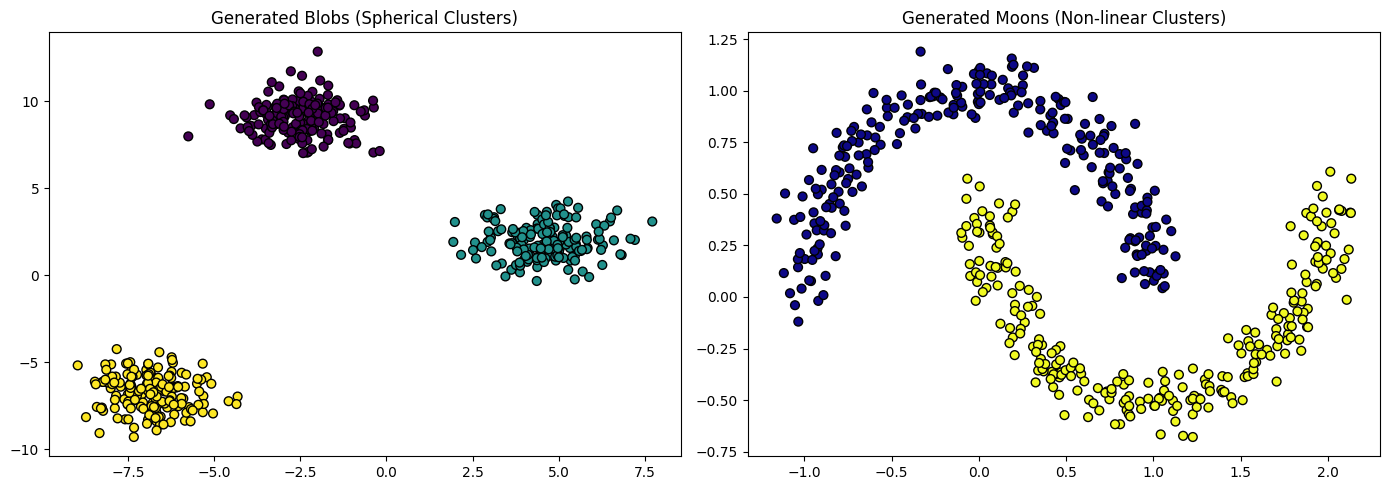

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='viridis', edgecolor='k', s=40)
axes[0].set_title("Generated Blobs (Spherical Clusters)")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='plasma', edgecolor='k', s=40)
axes[1].set_title("Generated Moons (Non-linear Clusters)")

plt.tight_layout()
plt.show()

In [23]:
scaler = StandardScaler()

X_blobs_scaled = scaler.fit_transform(X_blobs)
X_moons_scaled = scaler.fit_transform(X_moons)

In [48]:
kmeans_blobs = KMeans(n_clusters=3, random_state=42)
kmeans_moons = KMeans(n_clusters=2, random_state=42)

labels_kmeans_blobs = kmeans_blobs.fit_predict(X_blobs_scaled)
labels_kmeans_moons = kmeans_moons.fit_predict(X_moons_scaled)

In [49]:
dbscan_blobs = DBSCAN(eps=0.3, min_samples=5)
dbscan_moons = DBSCAN(eps=0.25, min_samples=5)

labels_dbscan_blobs = dbscan_blobs.fit_predict(X_blobs_scaled)
labels_dbscan_moons = dbscan_moons.fit_predict(X_moons_scaled)

C:\Users\ADARSH S SAHOO\AppData\Local\Temp\ipykernel_11024\2066392902.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 1].legend()


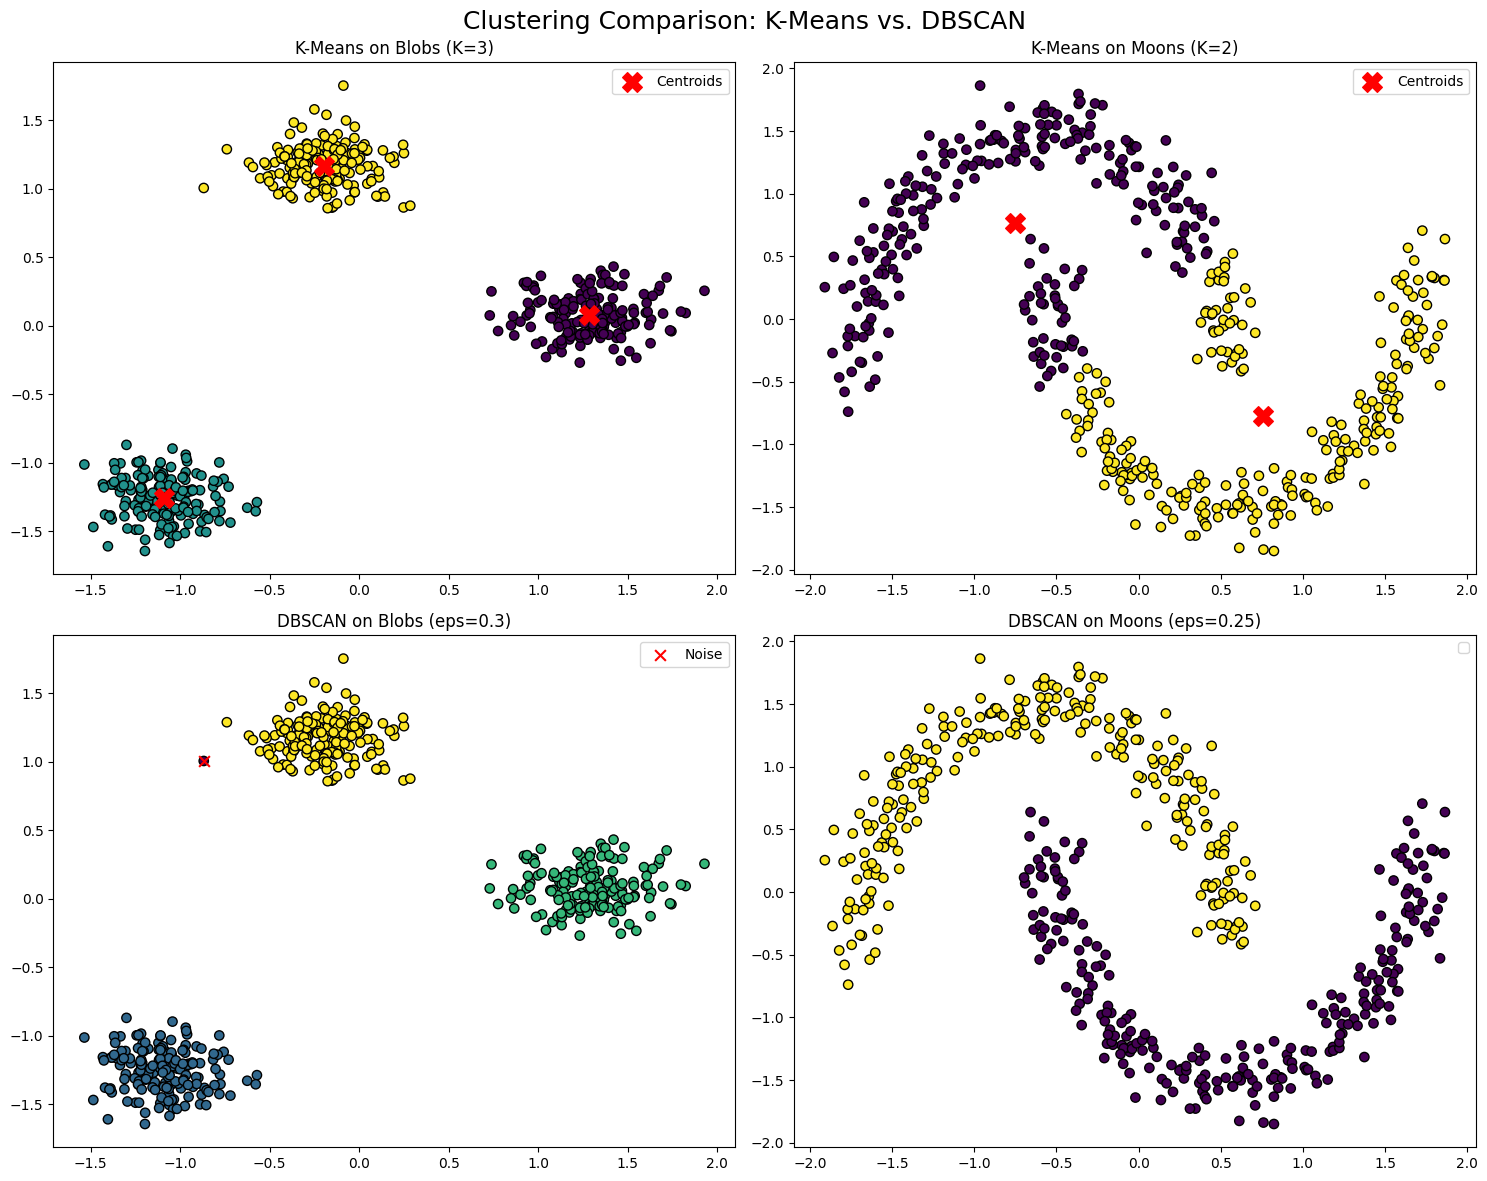

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# --- Row 1: K-Means Clustering ---
# Blobs
axes[0, 0].scatter(X_blobs_scaled[:, 0], X_blobs_scaled[:, 1], c=labels_kmeans_blobs, cmap='viridis', edgecolor='k', s=45)
axes[0, 0].scatter(kmeans_blobs.cluster_centers_[:, 0], kmeans_blobs.cluster_centers_[:, 1], 
                    c='red', marker='X', s=200, label='Centroids')
axes[0, 0].set_title("K-Means on Blobs (K=3)")
axes[0, 0].legend()

# Moons
axes[0, 1].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=labels_kmeans_moons, cmap='viridis', edgecolor='k', s=45)
axes[0, 1].scatter(kmeans_moons.cluster_centers_[:, 0], kmeans_moons.cluster_centers_[:, 1], 
                    c='red', marker='X', s=200, label='Centroids')
axes[0, 1].set_title("K-Means on Moons (K=2)")
axes[0, 1].legend()


# --- Row 2: DBSCAN Clustering ---
# Blobs
axes[1, 0].scatter(X_blobs_scaled[:, 0], X_blobs_scaled[:, 1], c=labels_dbscan_blobs, cmap='viridis', edgecolor='k', s=45)
# Check and plot noise points (represented by label -1)
noise_blobs = X_blobs_scaled[labels_dbscan_blobs == -1]
if len(noise_blobs) > 0:
    axes[1, 0].scatter(noise_blobs[:, 0], noise_blobs[:, 1], c='red', marker='x', s=60, label='Noise')
axes[1, 0].set_title("DBSCAN on Blobs (eps=0.3)")
axes[1, 0].legend()

# Moons
axes[1, 1].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=labels_dbscan_moons, cmap='viridis', edgecolor='k', s=45)
# Check and plot noise points
noise_moons = X_moons_scaled[labels_dbscan_moons == -1]
if len(noise_moons) > 0:
    axes[1, 1].scatter(noise_moons[:, 0], noise_moons[:, 1], c='red', marker='x', s=60, label='Noise')
axes[1, 1].set_title("DBSCAN on Moons (eps=0.25)")
axes[1, 1].legend()

plt.suptitle("Clustering Comparison: K-Means vs. DBSCAN", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()